In [1]:
import sys
from pathlib import Path

# プロジェクトのルートディレクトリをパスに追加
project_root = Path.cwd().parent.parent  # notebooks/assistments_2009_2010/ から2階層上がる
sys.path.insert(0, str(project_root))

print(f"Added to path: {project_root}")

import torch
import numpy as np
import pandas as pd
from typing import Dict, Any
import os

# 作業ディレクトリをプロジェクトルートに変更（この行を追加）
os.chdir(project_root)
print(f"Changed working directory to: {os.getcwd()}")

from src.utils.config_synthetic import load_yaml, generate_grid
from src.utils.seed import set_seed, derive_seed
from src.utils.device import get_device
from src.methods.registry import build_method
from src.datasets.generate_assistments_2009_2010_data import generate_data
from src.datasets.factory import build_dataset, build_test_dataset
from src.evaluation.evaluator import evaluate_testdata, evaluate_distribution


base_cfg = load_yaml("configs/Assistments_2009_2010/base.yaml")
train_cfg = load_yaml("configs/Assistments_2009_2010/train.yaml")
# ... 以下続く

device = get_device()
seed = 2  # 固定シード

# モデルと結果を保存する辞書
saved_methods = {}
saved_predictions = {}
saved_test_data = {}
saved_train_data = {}

for dataset_cfg in base_cfg["dataset"]:
    records = []  # データセットごとに初期化
    pre_current_dataset, pre_future_dataset = generate_data(data_dir=dataset_cfg["id"], n_skills=dataset_cfg["n_skills"])
    split_ratio = base_cfg["split_ratio"]
    print(pre_current_dataset.shape, pre_future_dataset.shape)

    print(f"=== Dataset: {dataset_cfg['name']} ===")
    print(f"Number of students: {len(pre_current_dataset)}")
    print(f"Number of skills: {dataset_cfg['n_skills']}")
    print(pre_current_dataset)
    print(pre_future_dataset)

    # seedを使ってシャッフル
    n_samples = len(pre_current_dataset)
    rng = np.random.RandomState(seed)
    indices = rng.permutation(n_samples)
    
    # シャッフルされたデータ
    shuffled_current = pre_current_dataset[indices]
    shuffled_future = pre_future_dataset[indices]
    
    # train/test分割
    split_idx = int(n_samples * split_ratio)
    current_dataset = shuffled_current[:split_idx]
    future_dataset = shuffled_future[:split_idx]
    test_future = shuffled_future[split_idx:]
    
    test_data = {
        "X_test": torch.from_numpy(test_future[:, 0, :]).to(device),
        "y_test": torch.from_numpy(test_future[:, 1, :]).to(device),
    }
    
    # データセット名でテストデータを保存
    dataset_name = dataset_cfg['name']
    saved_test_data[dataset_name] = test_data
    saved_methods[dataset_name] = {}
    saved_predictions[dataset_name] = {}
    saved_train_data[dataset_name] = {}
    
    for method_cfg in base_cfg["methods"]:
        method_seed = derive_seed(seed, method_cfg["id"])  # methodごとに分ける
        set_seed(method_seed)

        # exp_cfgを作成（proposedメソッドの場合のみ必要）
        if method_cfg["id"] in ["proposed", "full_information"]:
            exp_cfg = {
                "n_students": len(current_dataset),
                "n_skills": dataset_cfg["n_skills"],
                "dataset_name": dataset_cfg["name"],
            }
        else:
            exp_cfg = None

        # モデル定義
        method = build_method(
            method_cfg=method_cfg,
            device=device,
            seed=method_seed,
            exp_cfg=exp_cfg,
            training_cfg=train_cfg if exp_cfg is not None else None,
            save=False,
        )

        # モデル学習
        train_data = build_dataset(
            method_cfg=method_cfg,
            current_dataset=current_dataset,
            future_dataset=future_dataset,
            device=device,
        )
        method.fit(train_data)

        # テストデータ予測
        out = method.predict(test_data)

        # 評価
        test_metrics = base_cfg["evaluation"]["test_metrics"]

        scores_testdata = evaluate_testdata(
            pred=out,
            input=test_data["X_test"].cpu().numpy(),
            target=test_data["y_test"].cpu().numpy(),
            metrics=test_metrics,
        )
        record = {
            "seed": seed,
            "method": method_cfg["id"],
        }
        for k, v in scores_testdata.items():
            record[k] = v
        records.append(record)
        
        # モデル、予測結果、訓練データを保存
        method_name = method_cfg["id"]
        saved_methods[dataset_name][method_name] = method
        saved_predictions[dataset_name][method_name] = out
        saved_train_data[dataset_name][method_name] = train_data
        
        print(f"  Saved {method_name}: ACC={record.get('acc', 'N/A'):.4f}")

print("\n" + "="*80)
print("保存されたモデル:")
for dataset_name, methods in saved_methods.items():
    print(f"\n{dataset_name}:")
    for method_name in methods.keys():
        print(f"  - {method_name}")

Added to path: /Users/nagairyousuke/Documents/kashima_lab/master_paper
Changed working directory to: /Users/nagairyousuke/Documents/kashima_lab/master_paper
Using device: cpu
データセット生成完了:
  学生数: 39
  スキル数: 5
  前半平均習得率: 68.72%
  後半平均習得率（元）: 79.49%
  後半平均習得率（新）: 85.13%

スキル状態の変化:
  習得: 32件 (16.41%)
  ⚠️  喪失: 11件 (5.64%) → 論理和で修正済み
  維持: 123件 (63.08%)
  未習得: 29件 (14.87%)

学生ごとの習得スキル数:
  前半平均: 3.44 / 5
  後半平均（元）: 3.97 / 5
  後半平均（新）: 4.26 / 5
  平均純増: 0.82
  平均純増（元）: 0.54
(39, 2, 5) (39, 2, 5)
=== Dataset: s58_s74_s85_s277_s279 ===
Number of students: 39
Number of skills: 5
[[[0. 0. 0. 0. 0.]
  [1. 1. 0. 1. 0.]]

 [[0. 0. 0. 0. 0.]
  [1. 1. 0. 1. 0.]]

 [[0. 0. 0. 0. 0.]
  [1. 1. 1. 1. 1.]]

 [[0. 0. 0. 0. 0.]
  [0. 1. 1. 1. 1.]]

 [[0. 0. 0. 0. 0.]
  [1. 1. 0. 0. 0.]]

 [[0. 0. 0. 0. 0.]
  [1. 1. 1. 1. 1.]]

 [[0. 0. 0. 0. 0.]
  [1. 1. 1. 1. 1.]]

 [[0. 0. 0. 0. 0.]
  [1. 1. 1. 1. 1.]]

 [[0. 0. 0. 0. 0.]
  [0. 1. 1. 1. 1.]]

 [[0. 0. 0. 0. 0.]
  [1. 1. 1. 1. 1.]]

 [[0. 0. 0. 0. 0.]
  [1. 1


Dataset: S58_S74_S85_S277_S279

【評価結果】


,Method,ACC,SPA,ACE,MSE
0,proposed,1.0,1.0,0.000000e+00,0.000000e+00
1,full_information,1.0,1.0,0.000000e+00,0.000000e+00
2,popularity,1.0,1.0,6.938894e-18,3.081488e-34
3,simple_markov,1.0,1.0,0.000000e+00,0.000000e+00
4,random,1.0,1.0,0.000000e+00,0.000000e+00


データセット生成完了:
  学生数: 39
  スキル数: 5
  前半平均習得率: 68.72%
  後半平均習得率（元）: 79.49%
  後半平均習得率（新）: 85.13%

スキル状態の変化:
  習得: 32件 (16.41%)
  ⚠️  喪失: 11件 (5.64%) → 論理和で修正済み
  維持: 123件 (63.08%)
  未習得: 29件 (14.87%)

学生ごとの習得スキル数:
  前半平均: 3.44 / 5
  後半平均（元）: 3.97 / 5
  後半平均（新）: 4.26 / 5
  平均純増: 0.82
  平均純増（元）: 0.54

【Future Datasetの概要】
Current state (前半): shape=(39, 5)
Future state (後半): shape=(39, 5)


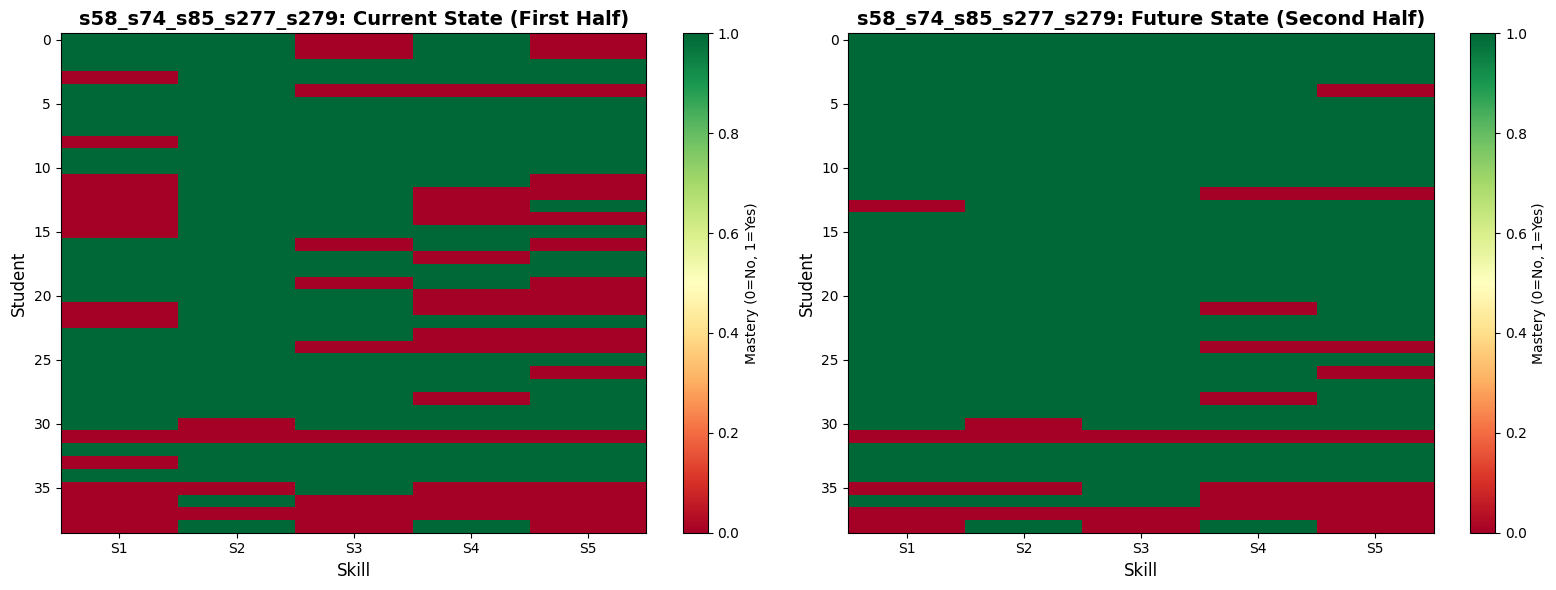


【テストデータとモデル出力の定性的比較】
テストサンプル数: 8

サンプル 1/8

現在の状態 (Current):  [1. 1. 1. 1. 1.]
正解の将来 (True):     [1. 1. 1. 1. 1.]
獲得スキル数: 0 スキル

【各手法の予測】

proposed            : [1. 1. 1. 1. 1.]
                      予測獲得数: 0.00, 誤差: 0.00
                      スキル別一致: [1 1 1 1 1], ACC: 100.00%

full_information    : [1. 1. 1. 1. 1.]
                      予測獲得数: 0.00, 誤差: 0.00
                      スキル別一致: [1 1 1 1 1], ACC: 100.00%

popularity          : [1. 1. 1. 1. 1.]
                      予測獲得数: 0.00, 誤差: 0.00
                      スキル別一致: [1 1 1 1 1], ACC: 100.00%

simple_markov       : [1. 1. 1. 1. 1.]
                      予測獲得数: 0.00, 誤差: 0.00
                      スキル別一致: [1 1 1 1 1], ACC: 100.00%

random              : [1. 1. 1. 1. 1.]
                      予測獲得数: 0.00, 誤差: 0.00
                      スキル別一致: [1 1 1 1 1], ACC: 100.00%

サンプル 2/8

現在の状態 (Current):  [0. 0. 0. 0. 0.]
正解の将来 (True):     [0. 0. 0. 0. 0.]
獲得スキル数: 0 スキル

【各手法の予測】

proposed            : [0. 0. 0. 0. 0.]
                

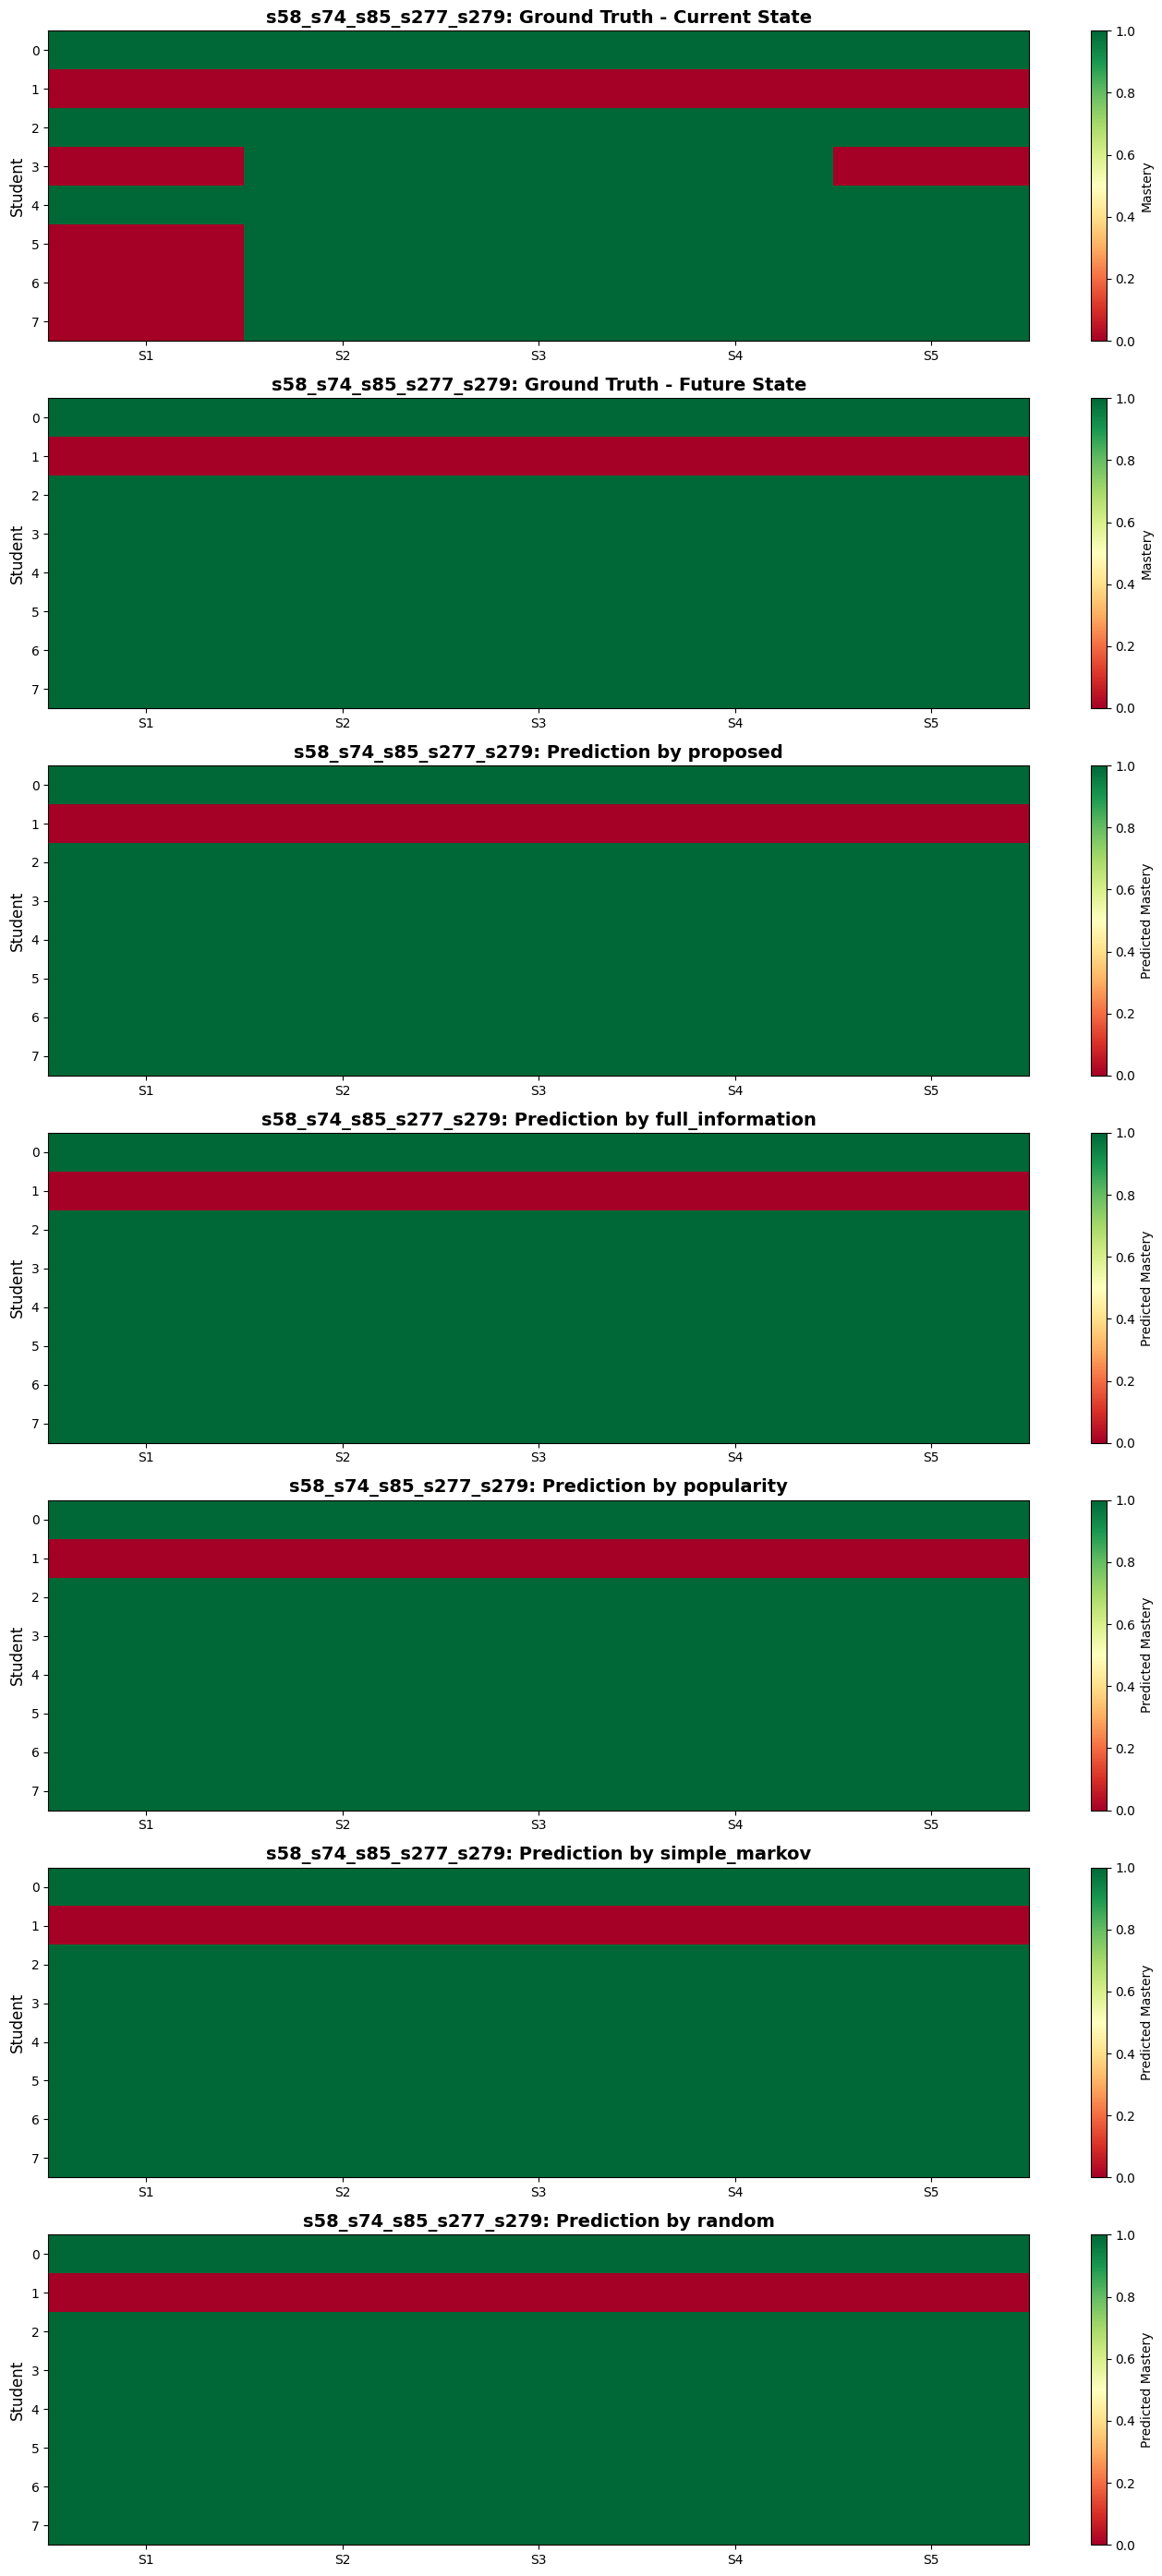


【誤差分析】


/var/folders/zg/773ptkr55z99zw26dvy19_v00000gn/T/ipykernel_34131/2477556452.py:182: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(error_data, labels=labels, patch_artist=True, showmeans=True)


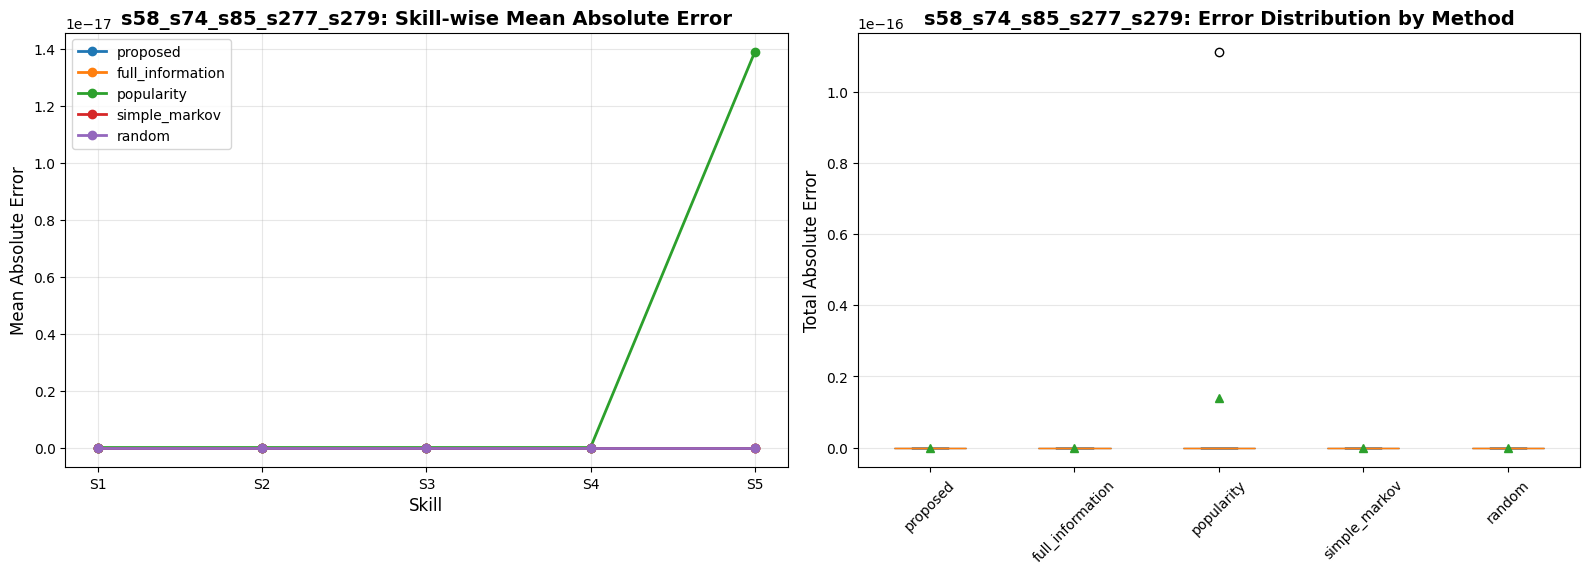


【Proposedモデルのパラメータ】

fc.weight:
  Shape: torch.Size([5, 5])
  Mean: -0.039608
  Std: 0.343038
  Min: -0.610675
  Max: 0.627838
  L1 norm: 6.555983
  Values:
tensor([[ 0.2793,  0.5481,  0.0436, -0.0078,  0.0100],
        [-0.1411,  0.4903,  0.4634, -0.0328,  0.6278],
        [ 0.0472, -0.0818,  0.0590, -0.1105, -0.4475],
        [-0.3443,  0.0962, -0.0348, -0.2861,  0.1180],
        [-0.5198, -0.1735, -0.4315, -0.5510, -0.6107]])

fc.bias:
  Shape: torch.Size([5])
  Mean: -0.092335
  Std: 0.045665
  Min: -0.152721
  Max: -0.034290
  L1 norm: 0.461677
  Values:
tensor([-0.1527, -0.1171, -0.0656, -0.0343, -0.0920])


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 結果の表示と可視化
for dataset_name in saved_methods.keys():
    print("\n" + "="*80)
    print(f"Dataset: {dataset_name.upper()}")
    print("="*80)
    
    # === 1. 各手法の評価結果 ===
    print("\n【評価結果】")
    results_summary = []
    for method_name, prediction in saved_predictions[dataset_name].items():
        test_data = saved_test_data[dataset_name]
        
        # 評価指標を計算
        scores = evaluate_testdata(
            pred=prediction,
            input=test_data["X_test"].cpu().numpy(),
            target=test_data["y_test"].cpu().numpy(),
            metrics=['acc', 'spa', 'ace', 'mse']
        )
        
        results_summary.append({
            'Method': method_name,
            'ACC': scores['acc'],
            'SPA': scores['spa'],
            'ACE': scores['ace'],
            'MSE': scores['mse']
        })
    
    df_results = pd.DataFrame(results_summary)
    display(df_results.sort_values('ACC', ascending=False))
    
    # === 2. Future Datasetの可視化 ===
    # データを再取得
    dataset_cfg = [d for d in base_cfg["dataset"] if d['name'] == dataset_name][0]
    pre_current_dataset, pre_future_dataset = generate_data(
        data_dir=dataset_cfg["id"], 
        n_skills=dataset_cfg["n_skills"]
    )
    
    current_skills = pre_future_dataset[:, 0, :]  # 現在の状態
    future_skills = pre_future_dataset[:, 1, :]   # 将来の状態
    n_skills = dataset_cfg["n_skills"]
    
    print("\n【Future Datasetの概要】")
    print(f"Current state (前半): shape={current_skills.shape}")
    print(f"Future state (後半): shape={future_skills.shape}")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 現在の状態のヒートマップ
    ax1 = axes[0]
    sample_size = min(50, len(current_skills))
    im1 = ax1.imshow(current_skills[:sample_size], cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax1.set_xlabel('Skill', fontsize=12)
    ax1.set_ylabel('Student', fontsize=12)
    ax1.set_title(f'{dataset_name}: Current State (First Half)', fontsize=14, fontweight='bold')
    ax1.set_xticks(range(n_skills))
    ax1.set_xticklabels([f'S{i+1}' for i in range(n_skills)])
    plt.colorbar(im1, ax=ax1, label='Mastery (0=No, 1=Yes)')
    
    # 将来の状態のヒートマップ
    ax2 = axes[1]
    im2 = ax2.imshow(future_skills[:sample_size], cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax2.set_xlabel('Skill', fontsize=12)
    ax2.set_ylabel('Student', fontsize=12)
    ax2.set_title(f'{dataset_name}: Future State (Second Half)', fontsize=14, fontweight='bold')
    ax2.set_xticks(range(n_skills))
    ax2.set_xticklabels([f'S{i+1}' for i in range(n_skills)])
    plt.colorbar(im2, ax=ax2, label='Mastery (0=No, 1=Yes)')
    
    plt.tight_layout()
    plt.show()
    
    # === 3. テストデータと各モデルの出力の定性的比較 ===
    print("\n【テストデータとモデル出力の定性的比較】")
    
    test_data = saved_test_data[dataset_name]
    X_test = test_data["X_test"].cpu().numpy()
    y_test = test_data["y_test"].cpu().numpy()
    
    n_test_samples = len(X_test)
    print(f"テストサンプル数: {n_test_samples}")
    
    # サンプル表示数
    display_samples = min(10, n_test_samples)
    
    for sample_idx in range(display_samples):
        print(f"\n{'='*80}")
        print(f"サンプル {sample_idx + 1}/{display_samples}")
        print(f"{'='*80}")
        
        current_state = X_test[sample_idx]
        true_future = y_test[sample_idx]
        
        print(f"\n現在の状態 (Current):  {current_state}")
        print(f"正解の将来 (True):     {true_future}")
        print(f"獲得スキル数: {(true_future - current_state).sum():.0f} スキル")
        
        # 各手法の予測を表示
        print("\n【各手法の予測】")
        for method_name, prediction in saved_predictions[dataset_name].items():
            pred_future = prediction[sample_idx]
            diff = pred_future - current_state
            error = np.abs(pred_future - true_future).sum()
            
            print(f"\n{method_name:20s}: {pred_future}")
            print(f"{'':20s}  予測獲得数: {diff.sum():.2f}, 誤差: {error:.2f}")
            
            # 正解との一致度（各スキル）
            matches = (np.round(pred_future) == true_future).astype(int)
            accuracy = matches.mean()
            print(f"{'':20s}  スキル別一致: {matches}, ACC: {accuracy:.2%}")
    
    # === 4. 予測分布の可視化（全テストサンプル） ===
    print("\n【予測分布の可視化】")
    
    n_methods = len(saved_predictions[dataset_name])
    fig, axes = plt.subplots(n_methods + 2, 1, figsize=(14, 4 * (n_methods + 2)))
    
    # Ground Truth: Current
    ax = axes[0]
    im = ax.imshow(X_test, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax.set_ylabel('Student', fontsize=12)
    ax.set_title(f'{dataset_name}: Ground Truth - Current State', fontsize=14, fontweight='bold')
    ax.set_xticks(range(n_skills))
    ax.set_xticklabels([f'S{i+1}' for i in range(n_skills)])
    plt.colorbar(im, ax=ax, label='Mastery')
    
    # Ground Truth: Future
    ax = axes[1]
    im = ax.imshow(y_test, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax.set_ylabel('Student', fontsize=12)
    ax.set_title(f'{dataset_name}: Ground Truth - Future State', fontsize=14, fontweight='bold')
    ax.set_xticks(range(n_skills))
    ax.set_xticklabels([f'S{i+1}' for i in range(n_skills)])
    plt.colorbar(im, ax=ax, label='Mastery')
    
    # 各手法の予測
    for idx, (method_name, prediction) in enumerate(saved_predictions[dataset_name].items()):
        ax = axes[idx + 2]
        im = ax.imshow(prediction, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
        ax.set_ylabel('Student', fontsize=12)
        ax.set_title(f'{dataset_name}: Prediction by {method_name}', fontsize=14, fontweight='bold')
        ax.set_xticks(range(n_skills))
        ax.set_xticklabels([f'S{i+1}' for i in range(n_skills)])
        plt.colorbar(im, ax=ax, label='Predicted Mastery')
    
    plt.tight_layout()
    plt.show()
    
    # === 5. 誤差分析 ===
    print("\n【誤差分析】")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 5-1. 各手法のスキル別平均誤差
    ax1 = axes[0]
    for method_name, prediction in saved_predictions[dataset_name].items():
        skill_errors = np.abs(prediction - y_test).mean(axis=0)
        ax1.plot(range(n_skills), skill_errors, marker='o', label=method_name, linewidth=2)
    
    ax1.set_xlabel('Skill', fontsize=12)
    ax1.set_ylabel('Mean Absolute Error', fontsize=12)
    ax1.set_title(f'{dataset_name}: Skill-wise Mean Absolute Error', fontsize=14, fontweight='bold')
    ax1.set_xticks(range(n_skills))
    ax1.set_xticklabels([f'S{i+1}' for i in range(n_skills)])
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # 5-2. 各手法の誤差分布（箱ひげ図）
    ax2 = axes[1]
    error_data = []
    labels = []
    for method_name, prediction in saved_predictions[dataset_name].items():
        errors = np.abs(prediction - y_test).sum(axis=1)
        error_data.append(errors)
        labels.append(method_name)
    
    bp = ax2.boxplot(error_data, labels=labels, patch_artist=True, showmeans=True)
    
    colors = plt.cm.Set3(range(len(labels)))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax2.set_ylabel('Total Absolute Error', fontsize=12)
    ax2.set_title(f'{dataset_name}: Error Distribution by Method', fontsize=14, fontweight='bold')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # === 6. モデルパラメータの確認（proposedとfull_informationのみ） ===
    if 'proposed' in saved_methods[dataset_name]:
        print("\n【Proposedモデルのパラメータ】")
        proposed = saved_methods[dataset_name]['proposed']
        if hasattr(proposed, 'model'):
            for name, param in proposed.model.named_parameters():
                print(f"\n{name}:")
                print(f"  Shape: {param.shape}")
                print(f"  Mean: {param.data.mean().item():.6f}")
                print(f"  Std: {param.data.std().item():.6f}")
                print(f"  Min: {param.data.min().item():.6f}")
                print(f"  Max: {param.data.max().item():.6f}")
                print(f"  L1 norm: {param.data.abs().sum().item():.6f}")
                
                if param.data.numel() <= 100:  # 小さいパラメータは全表示
                    print(f"  Values:\n{param.data}")